In [1]:
import os
import re
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
from matplotlib.font_manager import FontProperties
import pandas as pd
import datetime
import copy
# import scipy.stats as st
# from scipy.stats import linregress
import seaborn as sns
import colorcet as cc
# from sklearn.neighbors import KernelDensity
# from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

In [2]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            # Replace all occurrences of double slashes with a single slash
                            _fname = re.sub(r'/+', '/', fname[0])
                            files.append(_fname)
    return files

In [3]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    # "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_2location_'

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/envs_cases/'

# Domain 4 boundaries
# lon_range = [-65.4, -63.1]
# lat_range = [-33.3, -30.8]
# lon_range = [-65., -63.1]
lon_range = [-64.9, -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]

# Environment location (0: fixed site, 1: CI location)
env_loc = 0
# Time for representative environment
time_env = 0

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
# wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
# wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
# wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
# print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
# print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
# print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

files_d2, files_d3, files_d4, efiles_d2, efiles_d3, efiles_d4

Number of stats files (D2): 17
Number of ENV files (D2): 17
Number of stats files (D3): 17
Number of ENV files (D3): 17
Number of stats files (D4): 17
Number of ENV files (D4): 17


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181129/gefs03/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181129/gefs18/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181129/gefs00/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181129/gefs09/base/d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181204/gefs19/base/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181204/gefs18/base/d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20181205/gefs01/base/d2/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/20190122/gefs18/base/d2/stats/trackstats_2

In [4]:
figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/'

# CSAPR data directory
# dir_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/stats4lasso/'
dir_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/'
# dir_obs25 = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_celltracking.c1/stats/'
# dir_pixel_obs25 = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc2500mM1_gridded.c1/'
# dir_pixel_obs = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/celltracking/'
radar_lat = -32.1264
radar_lon = -64.7284
# Start/end hours for OBS
# shour_obs = '09'
# ehour_obs = '03'
shour_obs = '12'
ehour_obs = '00'

# basename_obs = 'csapr_trackstats_'
basename_obs = 'trackstats_'
basename_obs25 = 'trackstats_'
sat_basename = 'stats_goes16_'
env_basename = 'interpsonde_parameters_celltrack_'

statsfiles_obs = []
# statsfiles_obs25 = []
# satfiles_obs = []
envfiles_obs = []
# satfiles_obs25 = []
for idate in start_dates:
    statsfiles_obs.extend(sorted(glob.glob(f'{dir_obs}{basename_obs}{idate}*nc')))
    envfiles_obs.extend(sorted(glob.glob(f'{dir_obs}{env_basename}{idate}*nc')))
    # statsfiles_obs25.extend(sorted(glob.glob(f'{dir_obs25}{basename_obs25}{idate}*nc')))
    # satfiles_obs.extend(sorted(glob.glob(f'{dir_obs}{sat_basename}{idate}*nc')))
    # satfiles_obs25.extend(sorted(glob.glob(f'{dir_obs25}{sat_basename}{idate}*nc')))

print(f'Number of cases (OBS): {len(statsfiles_obs)}')
print(f'Number of environment files (OBS): {len(envfiles_obs)}')
# print(f'Number of cases (OBS 2.5km): {len(statsfiles_obs25)}')
# print(f'Number of satellite files (OBS): {len(satfiles_obs)}')
# print(f'Number of satellite (OBS 2.5km): {len(satfiles_obs25)}')
statsfiles_obs, envfiles_obs

Number of cases (OBS): 8
Number of environment files (OBS): 8


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190122.1200_20190123.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190123.1200_20190124.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfrppiqc500mM1_celltracking.c1/stats/trackstats_20190125.1200_20190126.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csapr/taranis_corcsapr2cfr

## Read and combine LASSO files

In [5]:
def read_combine_files(trackfiles, efiles):
    # Suppress the RuntimeWarning and FutureWarning from Xarray
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)

    # Initialize an empty list to hold the datasets
    dst_list = []
    
    # Loop over the track stats files and add a variable 'case'
    for i, file in enumerate(trackfiles):
        ds = xr.open_dataset(file)
        # Get parts from filename
        _parts = file.strip(os.sep).split(os.sep)
        _date = _parts[-6]
        _forcing = _parts[-5]
        _case = f"{_date}.{_forcing}"
        # Add a variable case (date.forcing) to the DataSet
        ds['case'] = _case
        dst_list.append(ds)
        
    # Concatenante the DataSets along the 'tracks' dimension
    dst = xr.concat(dst_list, dim='tracks')
    # Renumber tracks to make it continuous
    ntracks = dst.sizes['tracks']
    dst['tracks'] = np.arange(0, ntracks)
       
    # Read ENV data (drop 'height' dimension, i.e., profile variables)
    dse = xr.open_mfdataset(efiles, concat_dim='tracks', combine='nested').drop_dims('height')
    # Select location and representative time before CI
    dse = dse.sel(location=env_loc, times=time_env)
    dse['tracks'] = np.arange(0, ntracks)

    # Combine 2D and 3D datasets by coordinates
    ds = xr.combine_by_coords([dst, dse], combine_attrs='drop_conflicts')
    # ntimes = ds.sizes['times']
    ntracks = ds.sizes['tracks']
    print(f'Number of tracks: {ntracks}')

    return ds

In [6]:
# Read and combine D2 data
ds_d2 = read_combine_files(files_d2, efiles_d2)
ds_d2

Number of tracks: 6129


<xarray.Dataset> Size: 161MB
Dimensions:                  (tracks: 6129, times: 200)
Coordinates:
  * tracks                   (tracks) int64 49kB 0 1 2 3 ... 6125 6126 6127 6128
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 0
Data variables: (12/166)
    conv_core                (tracks) float32 25kB dask.array<chunksize=(1,), meta=np.ndarray>
    conv_mask                (tracks) float32 25kB dask.array<chunksize=(1,), meta=np.ndarray>
    dbz_comp                 (tracks) float32 25kB dask.array<chunksize=(1,), meta=np.ndarray>
    echotop10                (tracks) float32 25kB dask.array<chunksize=(1,), meta=np.ndarray>
    LWP                      (tracks) float32 25kB dask.array<chunksize=(1,), meta=np.ndarray>
    IWP                      (tracks) float32 25kB dask.array<chunksize=(1,), meta=np.ndarray>
    ...                       ...
    start_split_timeindex    (tracks) float64 49kB nan nan nan ... nan nan 36.0
    start_split_cloudnumber  (tracks) float64 49kB nan nan nan ... nan nan 1.0
    end_merge_tracknumber    (tracks) float64 49kB nan 32.0 nan ... nan nan
    end_merge_timeindex      (tracks) float64 49kB nan 10.0 nan ... 3.0 nan nan
    end_merge_cloudnumber    (tracks) float64 49kB nan 1.0 nan ... 2.0 nan nan
    case                     (tracks) <U15 368kB '20181129.gefs03' ... '20190...
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [7]:
# Read and combine D3 data
ds_d3 = read_combine_files(files_d3, efiles_d3)
ds_d3

Number of tracks: 10485


<xarray.Dataset> Size: 275MB
Dimensions:                  (tracks: 10485, times: 200)
Coordinates:
  * tracks                   (tracks) int64 84kB 0 1 2 3 ... 10482 10483 10484
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 0
Data variables: (12/166)
    conv_core                (tracks) float32 42kB dask.array<chunksize=(1,), meta=np.ndarray>
    conv_mask                (tracks) float32 42kB dask.array<chunksize=(1,), meta=np.ndarray>
    dbz_comp                 (tracks) float32 42kB dask.array<chunksize=(1,), meta=np.ndarray>
    echotop10                (tracks) float32 42kB dask.array<chunksize=(1,), meta=np.ndarray>
    LWP                      (tracks) float32 42kB dask.array<chunksize=(1,), meta=np.ndarray>
    IWP                      (tracks) float32 42kB dask.array<chunksize=(1,), meta=np.ndarray>
    ...                       ...
    start_split_timeindex    (tracks) float64 84kB nan nan nan ... nan 45.0 2.0
    start_split_cloudnumber  (tracks) float64 84kB nan nan nan ... nan 1.0 20.0
    end_merge_tracknumber    (tracks) float64 84kB 3.0 nan nan ... nan nan nan
    end_merge_timeindex      (tracks) float64 84kB 5.0 nan nan ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 84kB 1.0 nan nan ... nan nan nan
    case                     (tracks) <U15 629kB '20181129.gefs03' ... '20190...
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [8]:
# Read and combine D4 data
ds_d4 = read_combine_files(files_d4, efiles_d4)
ds_d4

Number of tracks: 8435


<xarray.Dataset> Size: 222MB
Dimensions:                  (tracks: 8435, times: 200)
Coordinates:
  * tracks                   (tracks) int64 67kB 0 1 2 3 ... 8431 8432 8433 8434
  * times                    (times) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
    location                 int64 8B 0
Data variables: (12/166)
    conv_core                (tracks) float32 34kB dask.array<chunksize=(1,), meta=np.ndarray>
    conv_mask                (tracks) float32 34kB dask.array<chunksize=(1,), meta=np.ndarray>
    dbz_comp                 (tracks) float32 34kB dask.array<chunksize=(1,), meta=np.ndarray>
    echotop10                (tracks) float32 34kB dask.array<chunksize=(1,), meta=np.ndarray>
    LWP                      (tracks) float32 34kB dask.array<chunksize=(1,), meta=np.ndarray>
    IWP                      (tracks) float32 34kB dask.array<chunksize=(1,), meta=np.ndarray>
    ...                       ...
    start_split_timeindex    (tracks) float64 67kB nan nan nan ... 42.0 nan 8.0
    start_split_cloudnumber  (tracks) float64 67kB nan nan nan ... 1.0 nan 1.0
    end_merge_tracknumber    (tracks) float64 67kB nan nan 12.0 ... nan nan nan
    end_merge_timeindex      (tracks) float64 67kB nan nan 1.0 ... nan nan nan
    end_merge_cloudnumber    (tracks) float64 67kB nan nan 3.0 ... nan nan nan
    case                     (tracks) <U15 506kB '20181129.gefs03' ... '20190...
Attributes:
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

## Read OBS data

In [9]:
# Read track data (OBS)
dst_o = xr.open_mfdataset(statsfiles_obs, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
ntracks_o = dst_o.sizes['tracks']
dst_o['tracks'] = np.arange(0, ntracks_o)
print(f'Number of tracks (OBS): {ntracks_o}')

# Read environment data (select relative time)
dse_o = xr.open_mfdataset(envfiles_obs, concat_dim='tracks', combine='nested').sel(reltime=0)
# Renumber tracks to make it continuous
dse_o['tracks'] = np.arange(0, ntracks_o)

# Combine datasets by coordinates
ds_o = xr.combine_by_coords([dst_o, dse_o], combine_attrs='drop_conflicts').load()
ds_o

Number of tracks (OBS): 542


<xarray.Dataset> Size: 5MB
Dimensions:                      (tracks: 542, times: 60)
Coordinates:
  * tracks                       (tracks) int64 4kB 0 1 2 3 ... 538 539 540 541
    reltime                      int64 8B 0
  * times                        (times) int64 480B 0 1 2 3 4 ... 55 56 57 58 59
Data variables: (12/281)
    time                         (tracks) datetime64[ns] 4kB 2018-11-29T15:30...
    tallenough_sfc               (tracks) float32 2kB 1.0 1.0 1.0 ... 1.0 1.0
    CAPE_sfc                     (tracks) float32 2kB 961.4 886.0 ... 586.3
    pseCAPE_sfc                  (tracks) float32 2kB 1.337e+03 ... 1.251e+03
    CIN_NA_sfc                   (tracks) float32 2kB -7.365 -8.484 ... -0.6641
    pseCIN_NA_sfc                (tracks) float32 2kB -6.735 -7.839 ... -0.4441
    ...                           ...
    start_split_tracknumber      (tracks) float64 4kB nan nan nan ... 20.0 37.0
    start_split_timeindex        (tracks) float64 4kB nan nan nan ... 6.0 1.0
    start_split_cloudnumber      (tracks) float64 4kB nan nan nan ... 1.0 4.0
    end_merge_tracknumber        (tracks) float64 4kB nan nan nan ... nan nan
    end_merge_timeindex          (tracks) float64 4kB nan nan nan ... nan nan
    end_merge_cloudnumber        (tracks) float64 4kB nan nan nan ... nan nan
Attributes:
    title:                 InterpSonde parameters matched to tracked cells
    Contact:               Zhe Feng, zhe.feng@pnnl.gov
    source_track_file:     /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csa...
    source_sonde_file:     /gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/csa...
    startdate:             20181129.1200
    enddate:               20181130.0000
    Title:                 Statistics of each track
    timegap_hour:          0.5
    time_resolution_hour:  0.25
    pixel_radius_km:       0.5

## Subset tracks

In [10]:
def subset_tracks(ds, lon_range, lat_range):
    # Get track min/max lat/lon
    minlon = ds['meanlon'].min(dim='times').load()
    maxlon = ds['meanlon'].max(dim='times').load()
    minlat = ds['meanlat'].min(dim='times').load()
    maxlat = ds['meanlat'].max(dim='times').load()
    # Get track lifetime in [minutes]
    # lifetime = (ds['track_duration'] * time_res).load()
    # Get track start time in decimal [hours]
    # start_hour = (ds['start_basetime'].dt.hour + ds['start_basetime'].dt.minute/60.).load()
    # Get track indices
    track_idx = np.where(
        (minlon >= np.min(lon_range)) & (maxlon <= np.max(lon_range)) & \
        (minlat >= np.min(lat_range)) & (maxlat <= np.max(lat_range))
        # (lifetime >= min(lifetime_range)) & (lifetime <= np.max(lifetime_range)) 
        # (start_hour >= np.min(hours_range)) & (start_hour <= np.max(hours_range))
    )[0]
    # Subset tracks
    dsout = ds.isel(tracks=track_idx)
    return dsout, track_idx

In [11]:
ds_o_s, track_idx = subset_tracks(ds_o, lon_range, lat_range)
ntracks_o = ds_o_s.sizes['tracks']
print(f'Number of tracks (OBS): {ntracks_o}')

Number of tracks (OBS): 379


In [12]:
ds_d2_s, track_idx = subset_tracks(ds_d2, lon_range, lat_range)
ntracks_d2 = ds_d2_s.sizes['tracks']
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 2876


In [13]:
ds_d3_s, track_idx = subset_tracks(ds_d3, lon_range, lat_range)
ntracks_d3 = ds_d3_s.sizes['tracks']
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 4727


In [14]:
ds_d4_s, track_idx = subset_tracks(ds_d4, lon_range, lat_range)
ntracks_d4 = ds_d4_s.sizes['tracks']
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 4324


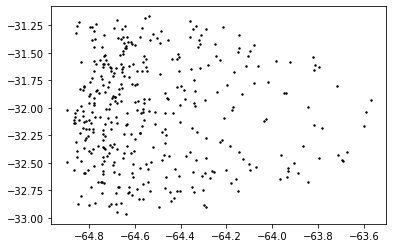

In [15]:
plt.scatter(ds_o_s['meanlon'].mean(dim='times'), ds_o_s['meanlat'].mean(dim='times'), s=2, c='k')
# plt.scatter(ds_o25_s['meanlon'].mean(dim='times'), ds_o25_s['meanlat'].mean(dim='times'), s=2, c='orange')

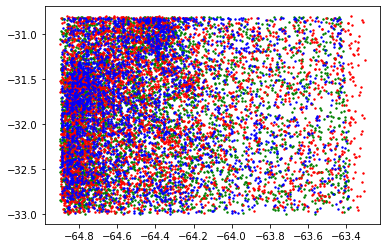

In [16]:
plt.scatter(ds_d3_s['meanlon'].mean(dim='times'), ds_d3_s['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4_s['meanlon'].mean(dim='times'), ds_d4_s['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2_s['meanlon'].mean(dim='times'), ds_d2_s['meanlat'].mean(dim='times'), s=2, c='b')

In [17]:
# Get unique case names
uniq_cases = np.unique(ds_d4_s.case)
uniq_cases

array(['20181129.gefs00', '20181129.gefs03', '20181129.gefs09',
       '20181129.gefs18', '20181204.gefs18', '20181204.gefs19',
       '20181205.gefs01', '20190122.gefs01', '20190122.gefs18',
       '20190123.eda05', '20190123.gefs18', '20190125.eda07',
       '20190125.gefs11', '20190129.eda09', '20190129.gefs11',
       '20190208.eda03', '20190208.eda08'], dtype='<U15')

In [18]:
# Convert case names to upper case
uniq_CASES = [s.upper() for s in uniq_cases]
uniq_CASES

['20181129.GEFS00',
 '20181129.GEFS03',
 '20181129.GEFS09',
 '20181129.GEFS18',
 '20181204.GEFS18',
 '20181204.GEFS19',
 '20181205.GEFS01',
 '20190122.GEFS01',
 '20190122.GEFS18',
 '20190123.EDA05',
 '20190123.GEFS18',
 '20190125.EDA07',
 '20190125.GEFS11',
 '20190129.EDA09',
 '20190129.GEFS11',
 '20190208.EDA03',
 '20190208.EDA08']

In [19]:
# def get_var_by_date(ds, varname, scale=1.0):
#     var_out = []
#     for idate in start_dates:
#         var_out.append(ds[varname].where(ds.start_basetime.dt.strftime('%Y%m%d') == idate, drop=True) * scale)
#     return var_out

In [20]:
# pELmu_date_o = get_var_by_date(ds_o_s, 'EL_height_mu', scale=1e-3)
# pELmu_date_d2 = get_var_by_date(ds_d2_s, 'pEL_height_mu', scale=1e-3)
# pELmu_date_d3 = get_var_by_date(ds_d3_s, 'pEL_height_mu', scale=1e-3)
# pELmu_date_d4 = get_var_by_date(ds_d4_s, 'pEL_height_mu', scale=1e-3)

In [98]:
# Simulation end times (00 UTC)
end_dates = pd.to_datetime(start_dates) + pd.Timedelta(1, 'D')
end_times = end_dates.strftime('%Y-%m-%dT%H')
end_times

Index(['2018-11-30T00', '2018-12-05T00', '2018-12-06T00', '2019-01-23T00',
       '2019-01-24T00', '2019-01-26T00', '2019-01-30T00', '2019-02-09T00'],
      dtype='object')

## Function to make Pandas DataFrame for BoxPlot

In [79]:
def make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, varname_o, varname_m, varname, scale=1.0):
    var_stack = np.hstack((ds_o_s[varname_o].values*scale, 
                           ds_d2_s[varname_m].values*scale, 
                           ds_d3_s[varname_m].values*scale,
                           ds_d4_s[varname_m].values*scale,))
    dates = np.hstack((ds_o_s.start_basetime.dt.strftime('%Y-%m-%d').values, 
                       ds_d2_s.start_basetime.dt.strftime('%Y-%m-%d').values,
                       ds_d3_s.start_basetime.dt.strftime('%Y-%m-%d').values,
                       ds_d4_s.start_basetime.dt.strftime('%Y-%m-%d').values,))
    times = np.hstack((ds_o_s.start_basetime.dt.strftime('%Y-%m-%dT%H').values, 
                       ds_d2_s.start_basetime.dt.strftime('%Y-%m-%dT%H').values,
                       ds_d3_s.start_basetime.dt.strftime('%Y-%m-%dT%H').values,
                       ds_d4_s.start_basetime.dt.strftime('%Y-%m-%dT%H').values,))
    sources = np.hstack((np.full(ds_o_s.sizes['tracks'], 'OBS'), 
                         np.full(ds_d2_s.sizes['tracks'], 'D2 (2.5 km)'),
                         np.full(ds_d3_s.sizes['tracks'], 'D3 (500 m)'),
                         np.full(ds_d4_s.sizes['tracks'], 'D4 (100 m)'),))
    data = {
        'Date': dates,
        'Time': times,
        varname: var_stack,
        'Source': sources,
    }
    # Create DataFrame
    df = pd.DataFrame(data)
    # # Convert 'Date' to datetime format (optional but recommended for date-based plotting)
    # df['Date'] = pd.to_datetime(df['Date'])
    # # Filter DataFrame to remove rows where the date is in end_dates
    # df = df[~df['Date'].isin(end_dates)]
    
    # Convert 'Date' to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    df['Time'] = pd.to_datetime(df['Time'])
    # Filter DataFrame to remove rows where the Time is in end_times
    # This is to remove entries where the date is the next date of the simulation
    df = df[~df['Time'].isin(end_times)]
    
    return df

In [80]:
_dates = pd.to_datetime(ds_d4_s.start_basetime)
target_datetime = pd.to_datetime('2019-01-24T00')
_dates[_dates == target_datetime]

DatetimeIndex(['2019-01-24', '2019-01-24', '2019-01-24', '2019-01-24'], dtype='datetime64[ns]', freq=None)

In [82]:
# df_pEL_height_mu = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'pseEL_height_mu', 'pEL_height_mu', 'LNB (km)', scale=1e-3)

### Instability metrics

In [83]:
df_pEL_height_mu = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'pseEL_height_mu', 'pEL_height_mu', 'LNB (km)', scale=1e-3)

df_pCAPE_mu = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'pseCAPE_mu', 'pCAPE_mu', 'MUCAPE (J/kg)', scale=1)

df_pCAPEacbl_mu = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'pseCAPEacbl_IB_mu', 'pCAPEacbl_mu', 'ACBL CAPE (J/kg)')

### Moisture metrics

In [84]:
# df_RHacbl = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'RH_mean_ACBL', 'RH_mean_ACBL', 'ACBL RH (%)')

df_RHlfc1500 = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'rh_at_pmuLFCplus1500m', 'rh_at_pmuLFCplus1500m', 'LFC+1.5km RH (%)')

df_RH850mb =  make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'rvap_850mb', 'rvap_850mb', '850hPa RH (%)')

df_RH600mb = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'rh_600mb', 'rh_600mb', '600hPa RH (%)')

# df_RH500mb = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'rh_500mb', 'rh_500mb', '500hPa RH (%)')

df_Q850mb = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'rvap_850mb', 'rvap_850mb', '850hPa Qv (g/kg)')

df_PW = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'PW_interpsonde', 'PW', 'PW (cm)')

### Low-level thermodynamics metrics

In [85]:
df_LCLz = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'LCL_height_ml', 'LCL_height_ml', 'LCL Height (km)')

df_LCLt = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'LCL_temp_mu', 'LCL_temp_mu', 'LCL Temperature (K)')

df_LFCz = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'LFC_height_mu', 'LFC_height_mu', 'LFC Height (km)')

### Shear metrics

In [86]:
df_BWS01km = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'shear_mag_bulk_0to1km', 'shear_mag_bulk_0to1km', '0-1km BWS (m/s)',)

df_BWS03km = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'shear_mag_bulk_0to3km', 'shear_mag_bulk_0to3km', '0-3km BWS (m/s)',)

df_BWS06km = make_df(ds_o_s, ds_d2_s, ds_d3_s, ds_d4_s, 'shear_mag_bulk_0to6km', 'shear_mag_bulk_0to6km', '0-6km BWS (m/s)',)

In [89]:
df_pCAPE_mu['Date'].unique()

array(['2018-11-29', '2018-12-04', '2018-12-05', '2019-01-22',
       '2019-01-23', '2019-01-25', '2019-01-29', '2019-02-08'],
      dtype=object)

In [92]:
df_pCAPE_mu.keys()

Index(['Date', 'Time', 'MUCAPE (J/kg)', 'Source'], dtype='object')

In [50]:
# ds_o_s

## Function to make boxplot nrow x ncol

In [95]:
def boxplot_MxN(nrow, ncol, data, wspace=None, hspace=None, bar_width=None, suptitle=None, fontsize=None,
                 titles=None, xlims=None, ylims=None, xlabels=None, ylabels=None, legend_loc='best', legend_labels=None, legend_fs=None,
                 dpi=300, figsize=None, figname=None):
    
    mpl.rcParams['font.family'] = 'Helvetica'
    mpl.rcParams['font.size'] = fontsize
    
    custom_palette = {
        'OBS': 'darkgray',
        'D2 (2.5 km)': 'dodgerblue',
        'D3 (500 m)': 'seagreen',
        'D4 (100 m)': 'darkviolet'
    }
    mean_colors = {
        'OBS': 'k',
        'D2 (2.5 km)': 'aquamarine',
        'D3 (500 m)': 'limegreen',
        'D4 (100 m)': 'magenta',
    }
    color_median = "orangered"
    lw = 1.
    gap = 0.2

    if figsize is None: figsize=(6 * ncol, 6 * nrow)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = gridspec.GridSpec(nrow, ncol, wspace=wspace, hspace=hspace)

    # Loop over row and column
    for row in range(nrow):
        for col in range(ncol):
            # Set up axis
            ax = fig.add_subplot(gs[row, col])
            idata = data[row][col]
            # Box plot
            sns.boxplot(
                x='Date', y=idata.keys()[2], hue='Source', data=idata, palette=custom_palette, showfliers=False,
                width=bar_width, dodge=True, gap=gap, ax=ax,
                showcaps=False, linewidth=lw,
                medianprops={"color": color_median, "linewidth": 3}
            )
            
            # # Customize boxplot outlines and whiskers
            # for patch in plt.gca().artists:  # Access each box's patch in the plot
            #     patch.set_edgecolor('black')  # Outline color
            #     patch.set_linewidth(lw)        # Outline thickness
            # for line in plt.gca().lines:      # Access whiskers and other lines
            #     line.set_linewidth(lw)         # Line thickness

            # # Overlay means using pointplot
            # for src in mean_colors.keys():
            #     sns.pointplot(
            #         x='Date', y='LNB', data=df[df['Source'] == src],
            #         color=mean_colors[src], ci=None, markers='o', 
            #     )

            plt.xticks(rotation=20, ha='right')
            ax.grid(ls=':', axis='y')
            ax.set_xlabel('')
            ax.set_title(titles[row][col], loc='left')
            ax.legend(title='', fontsize=legend_fs)       
            
            
    if (suptitle): fig.suptitle(suptitle, weight='bold')
    fig.savefig(figname, bbox_inches='tight', dpi=dpi, facecolor='w')
    return fig

4 3
/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/BoxplotByDate_CI_AMF_SondeParameters_obs_d2_d3_d4_4x3.png


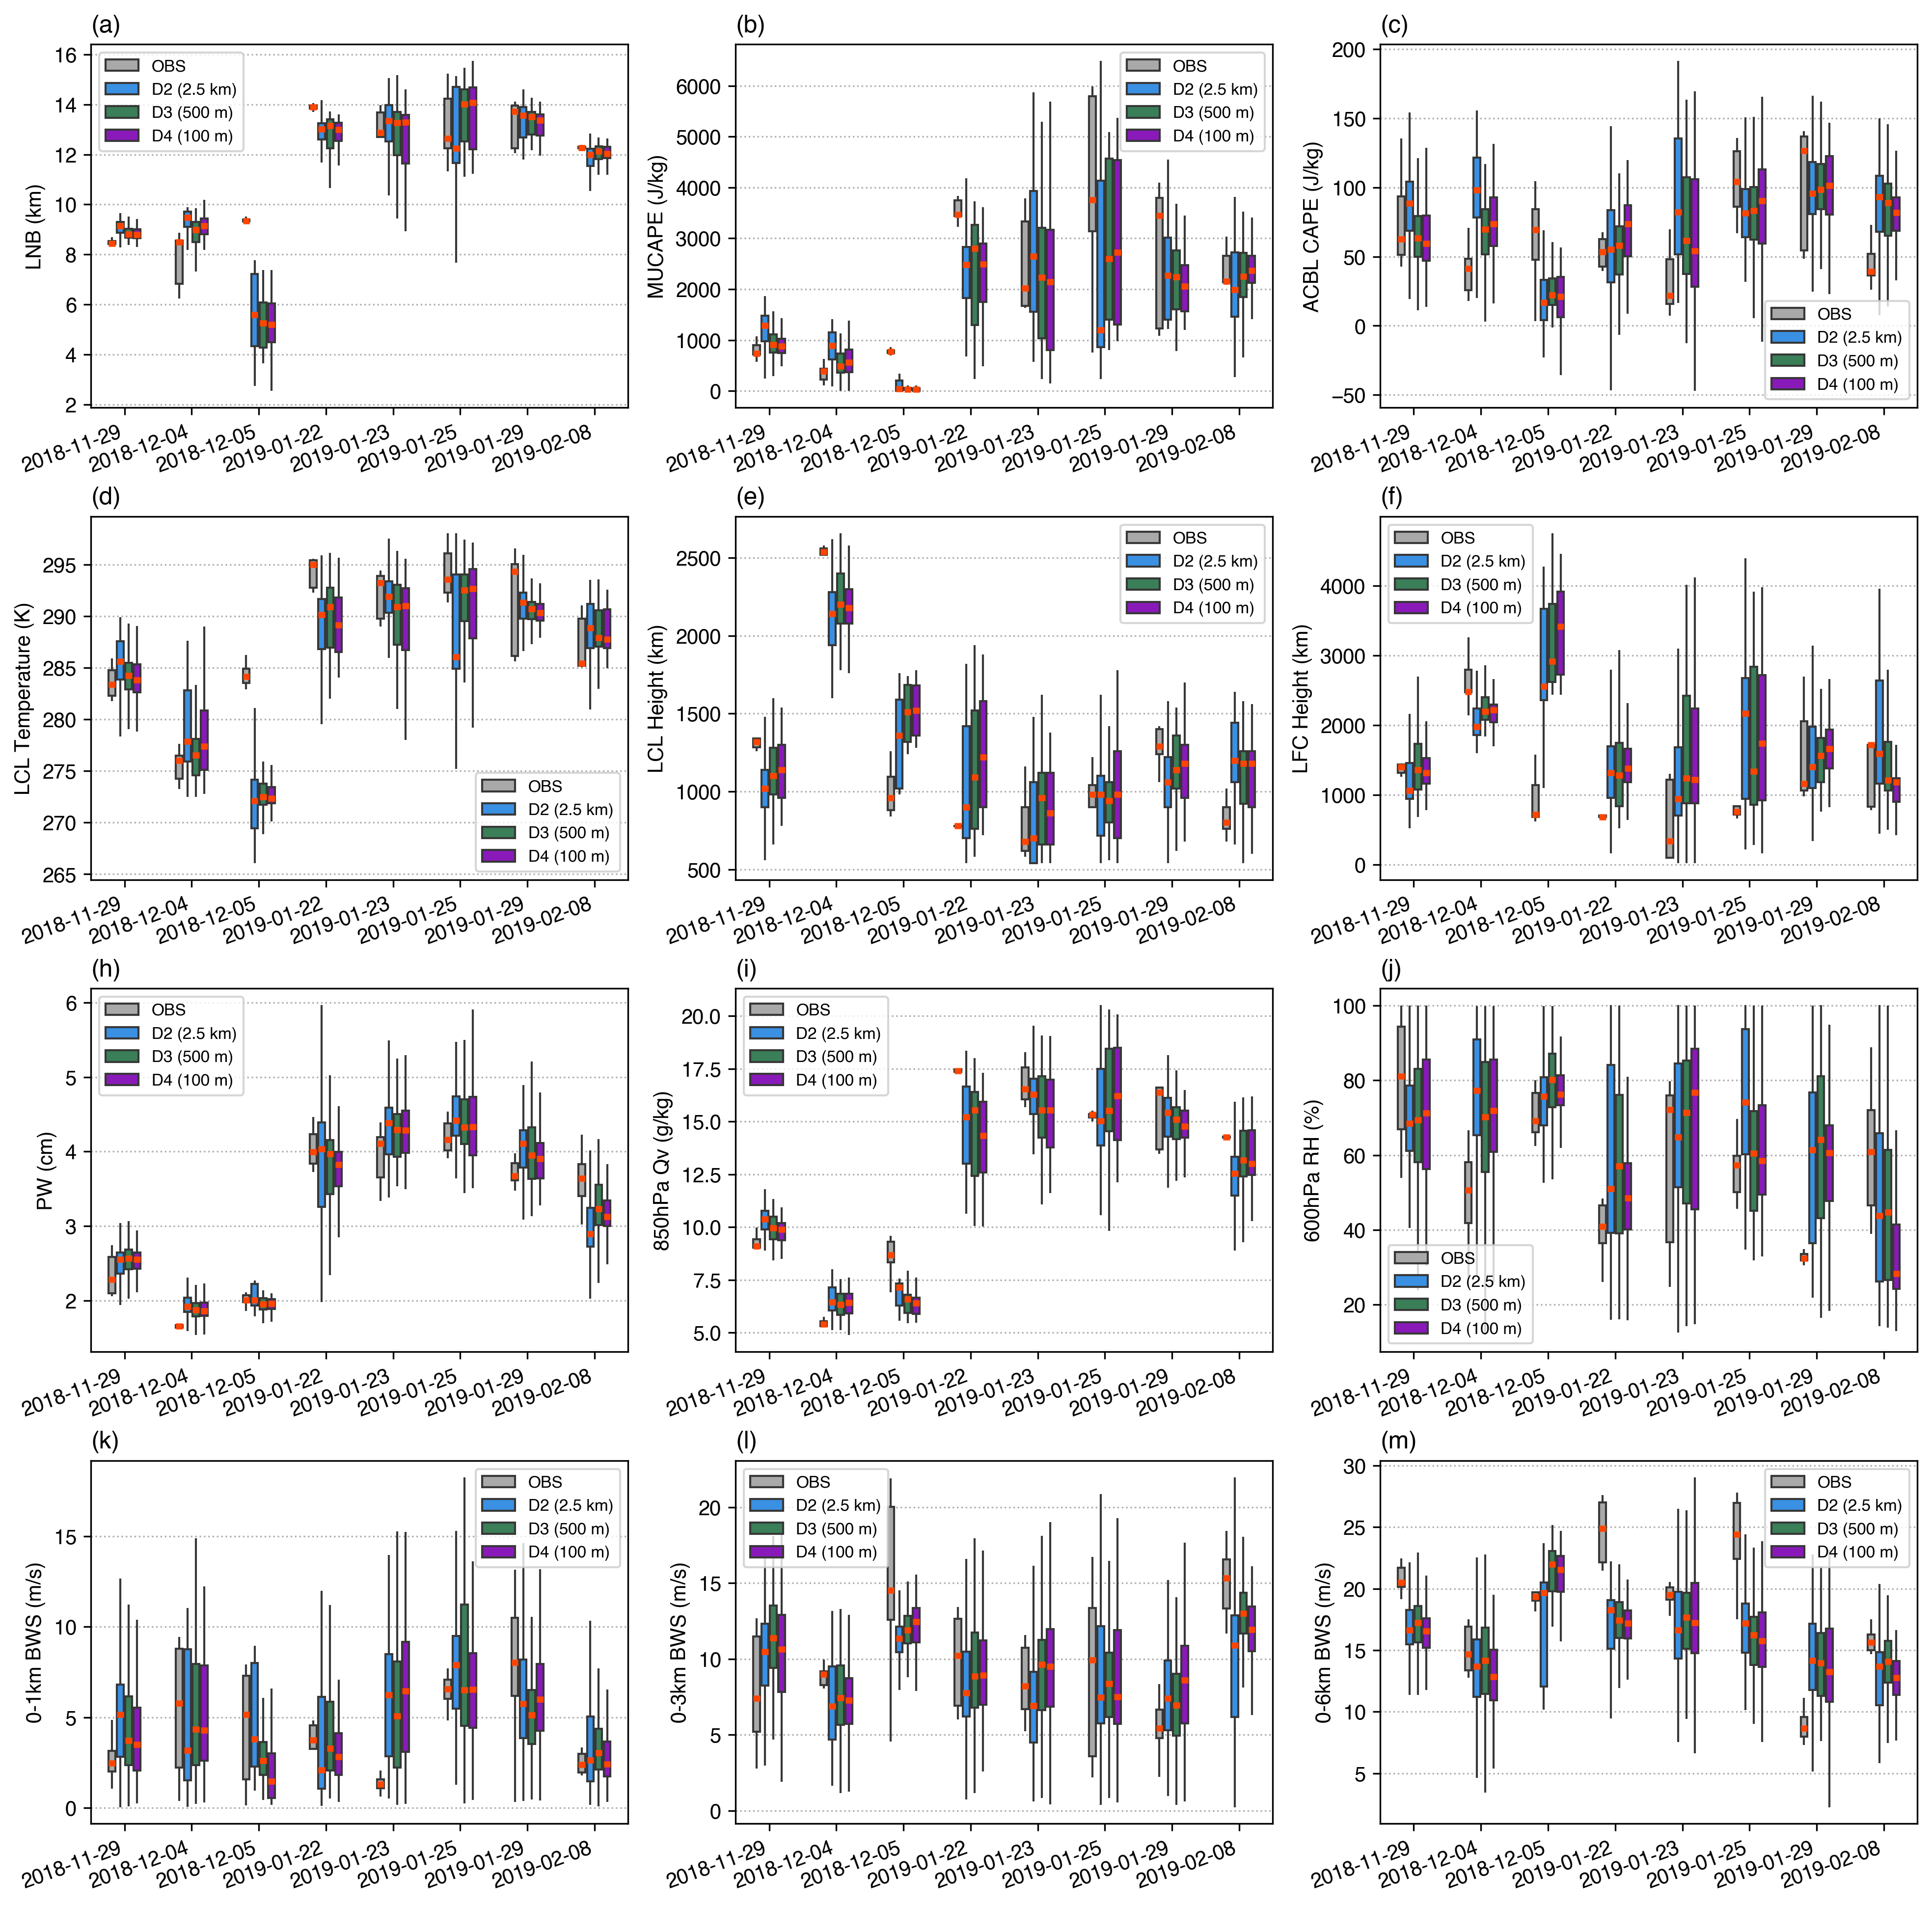

In [97]:
data_arr = [
    [df_pEL_height_mu, df_pCAPE_mu, df_pCAPEacbl_mu],
    [df_LCLt, df_LCLz, df_LFCz],
    [df_PW, df_Q850mb, df_RH600mb,],
    [df_BWS01km, df_BWS03km, df_BWS06km],
]
nrow = len(data_arr)
ncol = len(data_arr[0])
print(nrow, ncol)

xlabels = [['']*ncol]*nrow
titles = [['(a)', '(b)', '(c)'],['(d)','(e)','(f)'],['(h)','(i)','(j)'],['(k)','(l)','(m)'],]

legend_loc = 'lower right'
fontsize = 10
legend_fs = 8
figsize = (16,16)
# suptitle = ''
suptitle = None
wspace = 0.2
hspace = 0.3
bar_width = 0.5
figname = f'{figdir}BoxplotByDate_CI_AMF_SondeParameters_obs_d2_d3_d4_{nrow}x{ncol}.png'
print(figname)
fig = boxplot_MxN(nrow, ncol, data_arr, bar_width=bar_width, wspace=wspace, hspace=hspace, suptitle=suptitle, 
                   titles=titles, xlabels=xlabels, legend_loc=legend_loc, legend_fs=legend_fs,
                   fontsize=fontsize, figsize=figsize, figname=figname,)

In [ ]:
def fill_with_letters(matrix):
    # Flatten the matrix to get total elements and dimensions
    rows = len(matrix)
    cols = len(matrix[0]) if rows > 0 else 0
    
    # Generate letters in a flat list
    letters = [f"({chr(97 + i)})" for i in range(rows * cols)]
    
    # Fill 2D list with letters
    filled_matrix = [[letters[i * cols + j] for j in range(cols)] for i in range(rows)]
    
    return filled_matrix

In [ ]:
ncol = 3
matrix = [[None]*ncol]*nrow
# matrix = [[None]*ncol, 
#           [None, None, None], 
#           [None, None, None],]
result = fill_with_letters(matrix)
result

In [ ]:
f"({chr(98)})"

In [ ]:
# maxdbz_d2 = np.hstack((narrow_maxdbz_d2.values, wide_maxdbz_d2.values))
# CellType_d2 = np.hstack((np.full(len(narrow_maxdbz_d2), 'Narrow'), np.full(len(wide_maxdbz_d2), 'Wide')))

# maxdbz_d3 = np.hstack((narrow_maxdbz_d3.values, wide_maxdbz_d3.values))
# CellType_d3 = np.hstack((np.full(len(narrow_maxdbz_d3), 'Narrow'), np.full(len(wide_maxdbz_d3), 'Wide')))

# maxdbz_d4 = np.hstack((narrow_maxdbz_d4.values, wide_maxdbz_d4.values))
# CellType_d4 = np.hstack((np.full(len(narrow_maxdbz_d4), 'Narrow'), np.full(len(wide_maxdbz_d4), 'Wide')))

# # Create a DataFrame for each dataset
# df2 = pd.DataFrame({'Max Reflectivity (dBZ)': maxdbz_d2, 'Cell Type': CellType_d2, 'WRF': '2.5 km'})
# df3 = pd.DataFrame({'Max Reflectivity (dBZ)': maxdbz_d3, 'Cell Type': CellType_d3, 'WRF': '500 m'})
# df4 = pd.DataFrame({'Max Reflectivity (dBZ)': maxdbz_d4, 'Cell Type': CellType_d4, 'WRF': '100 m'})

# # Concatenate the DataFrames into one long DataFrame
# df_maxdbz = pd.concat([df2, df3, df4], ignore_index=True)

In [ ]:
# def plot_boxplots(data1, data2, data3, xlabel=None, ylabel=None, ylim=None, title=None, figsize=None, figname=None, bold_xlabel=False):

#     # plt.rcParams['font.family'] = 'DejaVu Serif'
#     plt.rcParams['font.family'] = 'Helvetica'
#     showfliers = False

#     # Create a figure and axis
#     fig, ax = plt.subplots(figsize=figsize, dpi=100)

#     x = np.arange(len(xlabel))  # the label locations
#     lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
#     name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

#     # Create boxplots with adjustable widths and closer spacing within groups
#     group_width = 1.0  # width for each group
#     box_width = 0.4  # width for each boxplot
#     group_spacing = 2  # space between groups

#     # Calculate positions for each box plot
#     positions1 = [i * group_spacing + 1 - box_width for i in range(len(data1))]
#     positions2 = [i * group_spacing + 1 for i in range(len(data2))]
#     positions3 = [i * group_spacing + 1 + box_width for i in range(len(data3))]

#     boxprops = dict(linewidth=1.5, edgecolor='k')
#     # medianprops = dict(linestyle='-', linewidth=2.5, color='red')
#     # meanprops = dict(marker='o', markerfacecolor='magenta', markeredgecolor='black')
#     medianprops1 = dict(linestyle='-', linewidth=2.5, color='aquamarine')
#     medianprops2 = dict(linestyle='-', linewidth=2.5, color='limegreen')
#     medianprops3 = dict(linestyle='-', linewidth=2.5, color='magenta')
#     meanprops1 = dict(marker='o', markerfacecolor='aquamarine', markeredgecolor='black')
#     meanprops2 = dict(marker='o', markerfacecolor='limegreen', markeredgecolor='black')
#     meanprops3 = dict(marker='o', markerfacecolor='magenta', markeredgecolor='black')

#     box1 = ax.boxplot(data1, positions=positions1, widths=box_width, patch_artist=True, boxprops=boxprops, medianprops=medianprops1, meanprops=meanprops1, showmeans=True, showfliers=showfliers)
#     box2 = ax.boxplot(data2, positions=positions2, widths=box_width, patch_artist=True, boxprops=boxprops, medianprops=medianprops2, meanprops=meanprops2, showmeans=True, showfliers=showfliers)
#     box3 = ax.boxplot(data3, positions=positions3, widths=box_width, patch_artist=True, boxprops=boxprops, medianprops=medianprops3, meanprops=meanprops3, showmeans=True, showfliers=showfliers)

#     # Set the face color for each group
#     colors1 = [lcolors['d2']]*len(xlabel)
#     colors2 = [lcolors['d3']]*len(xlabel)
#     colors3 = [lcolors['d4']]*len(xlabel)

#     for patch, color in zip(box1['boxes'], colors1):
#         patch.set_facecolor(color)
#     for patch, color in zip(box2['boxes'], colors2):
#         patch.set_facecolor(color)
#     for patch, color in zip(box3['boxes'], colors3):
#         patch.set_facecolor(color)

#     if bold_xlabel:
#         # Function to format labels
#         def format_label(label):
#             parts = label.split('.')
#             return f"$\\bf{{{parts[0]}}}$.{parts[1]}"

#         # Format xlabels
#         formatted_xlabels = [format_label(label) for label in xlabel]
#     else:
#         formatted_xlabels = xlabel

#     ax.set_xticks([i * group_spacing + 1 for i in range(len(data1))])
#     ax.set_xticklabels(formatted_xlabels, rotation=30, ha='right')
#     ax.set_ylabel(ylabel)
#     ax.set_title(title, loc='left')
#     if (ylim is not None): ax.set_ylim(min(ylim), max(ylim))
#     ax.grid(ls=':', axis='y')

#     # Add legend
#     legend_patches = [
#         mpl.patches.Patch(facecolor=lcolors['d2'], edgecolor=boxprops['edgecolor'], linewidth=boxprops['linewidth'], label=name_map['d2']),
#         mpl.patches.Patch(facecolor=lcolors['d3'], edgecolor=boxprops['edgecolor'], linewidth=boxprops['linewidth'], label=name_map['d3']),
#         mpl.patches.Patch(facecolor=lcolors['d4'], edgecolor=boxprops['edgecolor'], linewidth=boxprops['linewidth'], label=name_map['d4']),
#     ]
#     ax.legend(handles=legend_patches, loc='best')
    
#     # fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
#     return fig

In [ ]:
# xlabel = start_dates
# ylabel = 'LNB Height (km)'
# title = 'Level of Neutral Buoyancy'
# ylim = (5,17)
# figsize = [12,5]
# figname = f'{figdir}BoxplotByDate_obs_d2_d3_d4_pELmu.png'
# fig = plot_boxplots(pELmu_date_d2, pELmu_date_d3, pELmu_date_d4, ylim=ylim, xlabel=xlabel, ylabel=ylabel, title=title, figsize=figsize, figname=figname)